In [1]:
import os, sys, platform; print(f"{platform.python_implementation()} {platform.python_version()} | {platform.system()} {platform.release()} | CPU: {platform.processor() or platform.machine()} | logical CPUs: {os.cpu_count()}")

CPython 3.12.13 | Windows 11 | CPU: Intel64 Family 6 Model 151 Stepping 2, GenuineIntel | logical CPUs: 24


In [2]:
from pathlib import Path

# INPUT_PATH = Path(r"..\sample\PT\00013 Torso PET AC OSEM")
INPUT_PATH = Path(r"..\sample\nema\Multiframe\CT\DISCIMG\IMAGES\CT0001")
INPUT_PATH


WindowsPath('../sample/nema/Multiframe/CT/DISCIMG/IMAGES/CT0001')

# Basic 3D SimpleITK loading and geometry comparison

Use this notebook to compare how `SimpleITK` and `dicomsdl.simpleitk_bridge`
load a 3D volume.

`INPUT_PATH` can point to either:

- a DICOM series directory
- a single multiframe DICOM file

The goal here is not timing, but quick geometry, dtype, and array-layout checks.


In [3]:
import math
import sys
from pathlib import Path

import numpy as np


def _find_repo_root() -> Path:
    cwd = Path.cwd()
    if (cwd / "bindings" / "python" / "dicomsdl").is_dir():
        return cwd
    if cwd.name == "tutorials" and (cwd.parent / "bindings" / "python" / "dicomsdl").is_dir():
        return cwd.parent
    return cwd


def _load_simpleitk():
    try:
        import SimpleITK as sitk
    except ImportError as exc:
        raise RuntimeError(
            "SimpleITK is not installed. Install it with: pip install SimpleITK"
        ) from exc
    return sitk


def _read_with_simpleitk(input_path: Path):
    sitk = _load_simpleitk()
    if input_path.is_dir():
        series_ids = list(sitk.ImageSeriesReader.GetGDCMSeriesIDs(str(input_path)) or [])
        if len(series_ids) > 1:
            print(f"Multiple series IDs detected under {input_path}; using the first one: {series_ids[0]}")
        if series_ids:
            file_names = list(sitk.ImageSeriesReader.GetGDCMSeriesFileNames(str(input_path), series_ids[0]))
        else:
            file_names = list(sitk.ImageSeriesReader.GetGDCMSeriesFileNames(str(input_path)))
        if not file_names:
            raise RuntimeError(f"SimpleITK could not enumerate DICOM files under {input_path}")

        reader = sitk.ImageSeriesReader()
        reader.SetFileNames(file_names)
        reader.MetaDataDictionaryArrayUpdateOn()
        reader.LoadPrivateTagsOn()
        return reader.Execute()
    return sitk.ReadImage(str(input_path))


def _read_with_dicomsdl(input_path: Path):
    from dicomsdl.simpleitk_bridge import read_series_image

    return read_series_image(
        input_path,
        to_modality_value=True,
    )


def _simpleitk_array_from_image(image):
    sitk = _load_simpleitk()
    return np.array(sitk.GetArrayViewFromImage(image), copy=True)


def _print_simpleitk_summary(label, image):
    array = _simpleitk_array_from_image(image)
    print(label)
    print("  size:", tuple(int(v) for v in image.GetSize()))
    print("  spacing:", tuple(float(v) for v in image.GetSpacing()))
    print("  origin:", tuple(float(v) for v in image.GetOrigin()))
    print("  direction:", tuple(float(v) for v in image.GetDirection()))
    print("  shape:", tuple(int(v) for v in array.shape))
    print("  dtype:", array.dtype)
    print("  pixel type:", image.GetPixelIDTypeAsString())
    print("  range:", (array.min().item(), array.max().item()))
    return array


def _show_center_orthogonal_slices(image, array, label):
    import matplotlib.pyplot as plt

    if array.ndim != 3:
        raise RuntimeError(f"Expected a 3D scalar volume, got shape {array.shape}")

    spacing = tuple(abs(float(v)) for v in image.GetSpacing())
    center_z = array.shape[0] // 2
    center_y = array.shape[1] // 2
    center_x = array.shape[2] // 2

    axial_slice = array[center_z, :, :]
    coronal_slice = array[:, center_y, :]
    sagittal_slice = array[:, :, center_x]

    panels = [
        (
            "Axial",
            axial_slice,
            (0.0, axial_slice.shape[1] * spacing[0], axial_slice.shape[0] * spacing[1], 0.0),
            "X distance (mm)",
            "Y distance (mm)",
            f"z={center_z}",
        ),
        (
            "Coronal",
            coronal_slice,
            (0.0, coronal_slice.shape[1] * spacing[0], coronal_slice.shape[0] * spacing[2], 0.0),
            "X distance (mm)",
            "Slice axis distance (mm)",
            f"y={center_y}",
        ),
        (
            "Sagittal",
            sagittal_slice,
            (0.0, sagittal_slice.shape[1] * spacing[1], sagittal_slice.shape[0] * spacing[2], 0.0),
            "Y distance (mm)",
            "Slice axis distance (mm)",
            f"x={center_x}",
        ),
    ]

    print(f"{label} spacing: {spacing}")
    print(f"{label} center indices: z={center_z}, y={center_y}, x={center_x}")
    for plane_name, plane_slice, extent, _, _, plane_index in panels:
        width_mm = extent[1] - extent[0]
        height_mm = extent[2] - extent[3]
        print(
            f"{label} {plane_name.lower()} {plane_index}: "
            f"shape={plane_slice.shape}, display={width_mm:.3f} x {height_mm:.3f} mm"
        )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
    last_image = None
    for axis, (plane_name, plane_slice, extent, xlabel, ylabel, plane_index) in zip(axes, panels):
        last_image = axis.imshow(
            plane_slice,
            cmap="gray",
            extent=extent,
            aspect="equal",
            interpolation="nearest",
        )
        axis.set_title(f"{plane_name} ({plane_index})")
        axis.set_xlabel(xlabel)
        axis.set_ylabel(ylabel)

    fig.suptitle(f"{label} center orthogonal slices")
    if last_image is not None:
        fig.colorbar(last_image, ax=axes, shrink=0.9)
    plt.show()


def _max_abs_diff(lhs, rhs):
    lhs_values = tuple(float(value) for value in lhs)
    rhs_values = tuple(float(value) for value in rhs)
    if len(lhs_values) != len(rhs_values):
        return math.inf
    if not lhs_values:
        return 0.0
    return max(abs(a - b) for a, b in zip(lhs_values, rhs_values))


def _best_flip_match(lhs, rhs, *, rtol, atol):
    if lhs.ndim != 3 or rhs.ndim != 3 or lhs.shape != rhs.shape:
        return (None, False, math.inf, math.inf)

    best_label = None
    best_allclose = False
    best_max_abs = math.inf
    best_mean_abs = math.inf
    for flip_z in (False, True):
        for flip_y in (False, True):
            for flip_x in (False, True):
                if not (flip_z or flip_y or flip_x):
                    continue
                candidate = rhs
                labels = []
                if flip_z:
                    candidate = candidate[::-1, :, :]
                    labels.append("z")
                if flip_y:
                    candidate = candidate[:, ::-1, :]
                    labels.append("y")
                if flip_x:
                    candidate = candidate[:, :, ::-1]
                    labels.append("x")
                diff = np.abs(lhs - candidate)
                max_abs = float(diff.max())
                mean_abs = float(diff.mean())
                is_allclose = bool(np.allclose(lhs, candidate, rtol=rtol, atol=atol))
                if is_allclose and not best_allclose:
                    best_label = "+".join(labels)
                    best_allclose = True
                    best_max_abs = max_abs
                    best_mean_abs = mean_abs
                    continue
                if is_allclose == best_allclose and max_abs < best_max_abs:
                    best_label = "+".join(labels)
                    best_max_abs = max_abs
                    best_mean_abs = mean_abs
    return (best_label, best_allclose, best_max_abs, best_mean_abs)


def _compare_images(label_a, image_a, array_a, label_b, image_b, array_b, *, rtol=1e-5, atol=1e-4, geom_atol=1e-5):
    print(f"{label_a} size:", tuple(int(v) for v in image_a.GetSize()))
    print(f"{label_b} size:", tuple(int(v) for v in image_b.GetSize()))
    print(f"{label_a} dtype:", array_a.dtype)
    print(f"{label_b} dtype:", array_b.dtype)
    print()
    print(f"{label_a} spacing:", tuple(float(v) for v in image_a.GetSpacing()))
    print(f"{label_b} spacing:", tuple(float(v) for v in image_b.GetSpacing()))
    print(
        "spacing allclose:",
        np.allclose(image_a.GetSpacing(), image_b.GetSpacing(), atol=geom_atol, rtol=0.0),
        "max_abs_diff:",
        _max_abs_diff(image_a.GetSpacing(), image_b.GetSpacing()),
    )
    print()
    print(f"{label_a} origin:", tuple(float(v) for v in image_a.GetOrigin()))
    print(f"{label_b} origin:", tuple(float(v) for v in image_b.GetOrigin()))
    print(
        "origin allclose:",
        np.allclose(image_a.GetOrigin(), image_b.GetOrigin(), atol=geom_atol, rtol=0.0),
        "max_abs_diff:",
        _max_abs_diff(image_a.GetOrigin(), image_b.GetOrigin()),
    )
    print()
    print(f"{label_a} direction:", tuple(float(v) for v in image_a.GetDirection()))
    print(f"{label_b} direction:", tuple(float(v) for v in image_b.GetDirection()))
    print(
        "direction allclose:",
        np.allclose(image_a.GetDirection(), image_b.GetDirection(), atol=geom_atol, rtol=0.0),
        "max_abs_diff:",
        _max_abs_diff(image_a.GetDirection(), image_b.GetDirection()),
    )
    print()
    print(f"{label_a} shape:", array_a.shape)
    print(f"{label_b} shape:", array_b.shape)
    same_shape = array_a.shape == array_b.shape
    print("same shape:", same_shape)
    if not same_shape:
        return

    lhs = array_a.astype(np.float64, copy=False)
    rhs = array_b.astype(np.float64, copy=False)
    diff = np.abs(lhs - rhs)
    direct_equal = np.array_equal(array_a, array_b)
    direct_allclose = bool(np.allclose(lhs, rhs, rtol=rtol, atol=atol))
    print("direct equal:", direct_equal)
    print(f"direct allclose: {direct_allclose} (rtol={rtol}, atol={atol})")
    print("direct max_abs_diff:", float(diff.max()))
    print("direct mean_abs_diff:", float(diff.mean()))

    if lhs.ndim == 3 and not direct_allclose:
        best_label, best_allclose, best_max_abs, best_mean_abs = _best_flip_match(
            lhs,
            rhs,
            rtol=rtol,
            atol=atol,
        )
        if best_label is not None:
            print(f"best axis flip: {best_label}")
            print("best flip allclose:", best_allclose)
            print("best flip max_abs_diff:", best_max_abs)
            print("best flip mean_abs_diff:", best_mean_abs)


REPO_ROOT = _find_repo_root()
repo_python_dir = REPO_ROOT / "bindings" / "python"
if repo_python_dir.is_dir():
    repo_python_text = str(repo_python_dir)
    if repo_python_text not in sys.path:
        sys.path.insert(0, repo_python_text)

INPUT_PATH = Path(INPUT_PATH)
if not INPUT_PATH.is_absolute():
    INPUT_PATH = (REPO_ROOT / INPUT_PATH).resolve()
if not INPUT_PATH.exists():
    raise FileNotFoundError(INPUT_PATH)

print(f"Repo root: {REPO_ROOT}")
print(f"Input path: {INPUT_PATH}")
print(f"Input kind: {'directory series' if INPUT_PATH.is_dir() else 'single file'}")


Repo root: C:\Lab\workspace\test.git
Input path: C:\Lab\workspace\sample\nema\Multiframe\CT\DISCIMG\IMAGES\CT0001
Input kind: single file


## Native `SimpleITK` reader

This uses `SimpleITK.ImageSeriesReader` for a directory series and `sitk.ReadImage`
for a single file.


In [4]:
simpleitk_image = _read_with_simpleitk(INPUT_PATH)
simpleitk_array = _print_simpleitk_summary(
    "SimpleITK.ImageSeriesReader / ReadImage",
    simpleitk_image,
)

SimpleITK.ImageSeriesReader / ReadImage
  size: (512, 512, 54)
  spacing: (0.597656, 0.597656, 3.0)
  origin: (-94.7012, -312.701, -806.5)
  direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -1.0)
  shape: (54, 512, 512)
  dtype: int32
  pixel type: 32-bit signed integer
  range: (-1024, 3071)


## Center orthogonal slices from `SimpleITK`

This first view uses the geometry reported directly by the native SimpleITK reader.


SimpleITK spacing: (0.597656, 0.597656, 3.0)
SimpleITK center indices: z=27, y=256, x=256
SimpleITK axial z=27: shape=(512, 512), display=306.000 x 306.000 mm
SimpleITK coronal y=256: shape=(54, 512), display=306.000 x 162.000 mm
SimpleITK sagittal x=256: shape=(54, 512), display=306.000 x 162.000 mm


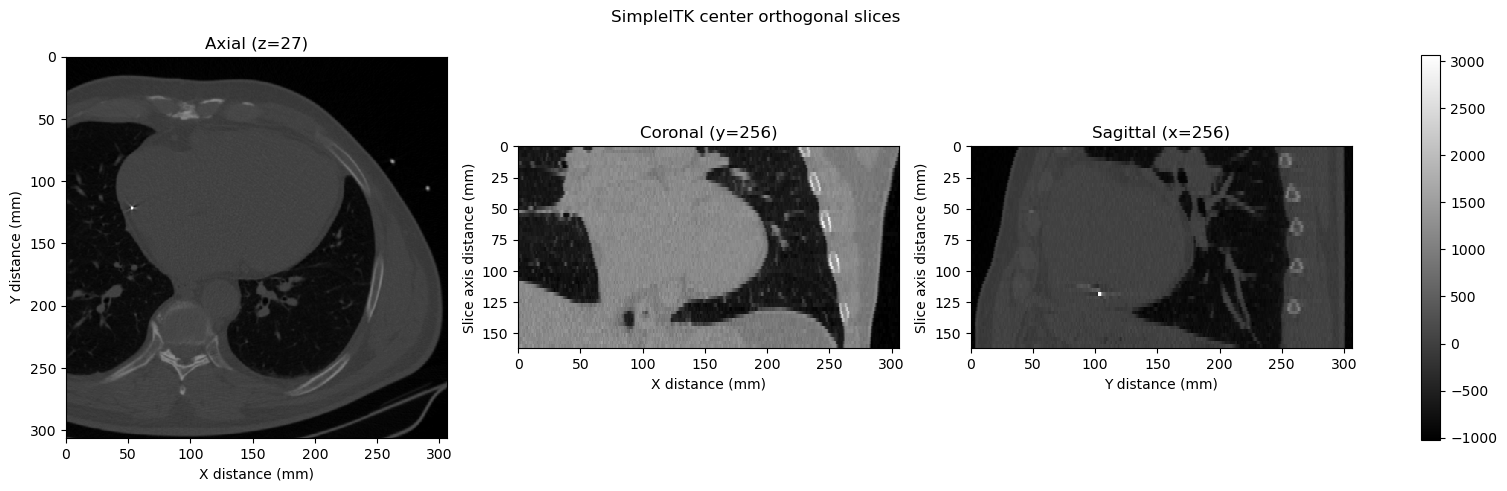

In [5]:
_show_center_orthogonal_slices(
    simpleitk_image,
    simpleitk_array,
    "SimpleITK",
)

## `dicomsdl.simpleitk_bridge.read_series_image`

This bridge returns a normal `SimpleITK.Image` while canonicalizing 3D stacks
into physical slice order with positive slice spacing.


In [6]:
dicomsdl_image = _read_with_dicomsdl(INPUT_PATH)
dicomsdl_array = _print_simpleitk_summary(
    "dicomsdl.simpleitk_bridge.read_series_image",
    dicomsdl_image,
)

dicomsdl.simpleitk_bridge.read_series_image
  size: (512, 512, 54)
  spacing: (0.597656, 0.597656, 3.0)
  origin: (-94.7012, -312.701, -965.5)
  direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
  shape: (54, 512, 512)
  dtype: int16
  pixel type: 16-bit signed integer
  range: (-1024, 3071)


## Center orthogonal slices from `dicomsdl`

This uses the canonical `dicomsdl.simpleitk_bridge` geometry directly, so the
slice axis may look reversed relative to some native readers when the bridge
reorders the stack into positive-spacing physical order.

This is not a raw in-memory z flip with geometry left untouched. The bridge
reorders the voxel stack into physical slice order and updates `origin` and
`direction` consistently so that `spacing[2]` stays positive, the stack axis is
carried by `direction`, and the image-axis basis stays right-handed in physical
space.

Note that the anatomy may not match a casual screen-based expectation of
"up/down" or "left/right". That does not necessarily mean the volume is wrong.
For a human patient, the DICOM patient-based coordinate system defines the
positive axes as right-to-left for *x*, anterior-to-posterior for *y*, and
feet-to-head for *z*.

Reference:
https://dicom.nema.org/medical/dicom/current/output/chtml/part03/sect_C.7.6.2.html#sect_C.7.6.2.1.1


dicomsdl spacing: (0.597656, 0.597656, 3.0)
dicomsdl center indices: z=27, y=256, x=256
dicomsdl axial z=27: shape=(512, 512), display=306.000 x 306.000 mm
dicomsdl coronal y=256: shape=(54, 512), display=306.000 x 162.000 mm
dicomsdl sagittal x=256: shape=(54, 512), display=306.000 x 162.000 mm


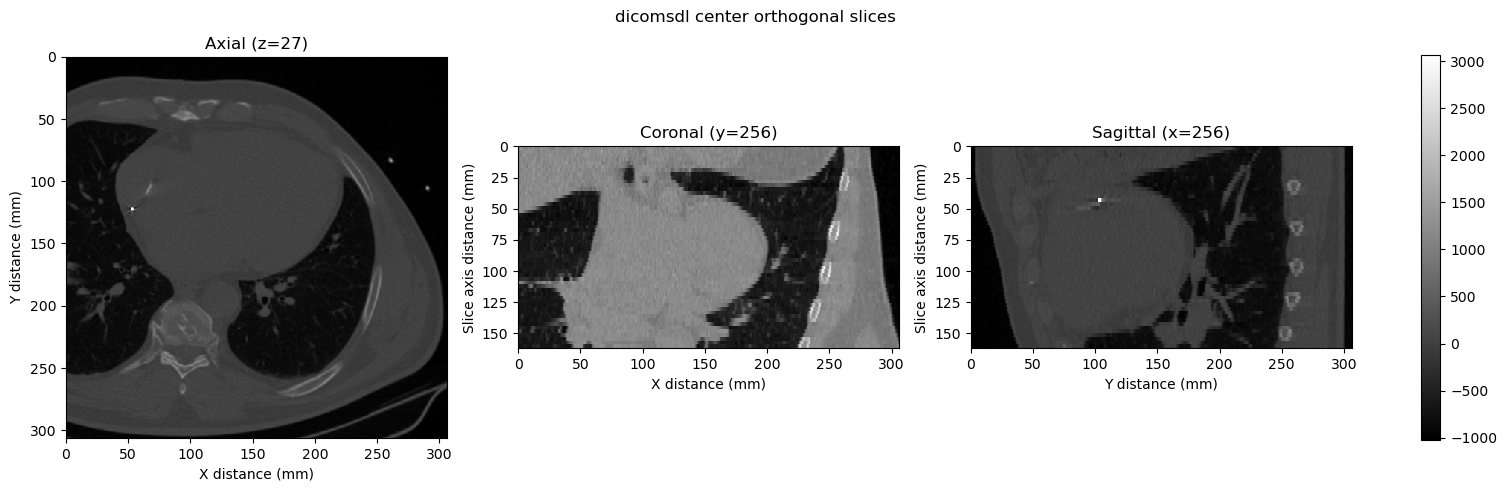

In [7]:
_show_center_orthogonal_slices(
    dicomsdl_image,
    dicomsdl_array,
    "dicomsdl",
)

## Geometry and array-layout comparison

For a regular 3D stack, the two readers may expose different dtypes or slice-axis
direction even when the underlying voxel values come from the same source data.

For stack-like 3D inputs, native readers may preserve a storage order that
differs from the bridge's canonical physical slice order. In that case the
bridge can differ by a z-axis flip plus corresponding `origin` and `direction`
changes, while still representing the same physical volume.

That canonicalization makes downstream physical-coordinate, vector, and reslice
work more consistent across file-per-slice series and multiframe inputs and
helps keep a right-handed physical image basis, at the cost of no longer
preserving the native raw frame order.


In [8]:
_compare_images(
    "SimpleITK",
    simpleitk_image,
    simpleitk_array,
    "dicomsdl",
    dicomsdl_image,
    dicomsdl_array,
)

SimpleITK size: (512, 512, 54)
dicomsdl size: (512, 512, 54)
SimpleITK dtype: int32
dicomsdl dtype: int16

SimpleITK spacing: (0.597656, 0.597656, 3.0)
dicomsdl spacing: (0.597656, 0.597656, 3.0)
spacing allclose: True max_abs_diff: 0.0

SimpleITK origin: (-94.7012, -312.701, -806.5)
dicomsdl origin: (-94.7012, -312.701, -965.5)
origin allclose: False max_abs_diff: 159.0

SimpleITK direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -1.0)
dicomsdl direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
direction allclose: False max_abs_diff: 2.0

SimpleITK shape: (54, 512, 512)
dicomsdl shape: (54, 512, 512)
same shape: True
direct equal: False
direct allclose: False (rtol=1e-05, atol=0.0001)
direct max_abs_diff: 3228.0
direct mean_abs_diff: 264.1568433973524
best axis flip: z
best flip allclose: True
best flip max_abs_diff: 0.0
best flip mean_abs_diff: 0.0
